# 04 — Tire Risk Model Design & Decision Rules

**Purpose:** Build, validate, and export a conservative, explainable Tire Risk Model from the engineered dataset. Produce a score (0–1), risk bucket, recommended action, and a maintenance priority ranking. Provide diagnostics so later you can tweak weights or add features.

| Item | Value |
|------|-------|
| **Input** | `data/processed/cleaned_configuration_data.csv` |
| **Outputs** | `data/enriched/tire_intelligence_v1.csv`, `data/enriched/maintenance_report_v1.csv`, `data/enriched/model.info.json` |
| **Author** | TPMS Engineering Team |
| **Date** | 2026-03-02 |
| **Model Version** | v0.1-stress |

---
## 1 · Imports & Configuration

All hyperparameters live in the `CONFIG` block below.  
Re-run the notebook after tweaking to see the effect instantly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import json, os, itertools

# ── CONFIG ────────────────────────────────────────────────────────────
CONFIG = {
    # Stress score weights (must sum to 1.0)
    'WEIGHT_LOAD':    0.8,
    'WEIGHT_DRIVEN':  0.2,

    # Risk-level thresholds
    'THRESH_LOW':     0.4,
    'THRESH_HIGH':    0.7,

    # Maintenance-priority epsilon (avoid div-by-zero)
    'EPSILON':        1.0,

    # Adjusted-score weights (cell 8)
    'ALPHA': 0.7,
    'BETA':  0.2,
    'GAMMA': 0.1,

    # Sensitivity sweep ranges
    'LOAD_WEIGHT_RANGE':  np.arange(0.60, 0.95, 0.05),
    'THRESH_HIGH_RANGE':  np.arange(0.55, 0.85, 0.05),

    # Top-N for ops report
    'TOP_N': 5,

    # Model version string
    'MODEL_VERSION': 'v0.1-stress',

    # Paths
    'INPUT_PATH':   r'E:\TPMS\data\processed\cleaned_configuration_data.csv',
    'OUTPUT_DIR':   r'E:\TPMS\data\enriched',
}

# Derived paths
CONFIG['INTELLIGENCE_PATH'] = os.path.join(CONFIG['OUTPUT_DIR'], 'tire_intelligence_v1.csv')
CONFIG['REPORT_PATH']       = os.path.join(CONFIG['OUTPUT_DIR'], 'maintenance_report_v1.csv')
CONFIG['MODEL_INFO_PATH']   = os.path.join(CONFIG['OUTPUT_DIR'], 'model.info.json')

# Run timestamp & model version
RUN_TIMESTAMP  = pd.Timestamp.utcnow().isoformat()
MODEL_VERSION  = CONFIG['MODEL_VERSION']

print(f'Run timestamp : {RUN_TIMESTAMP}')
print(f'Model version : {MODEL_VERSION}')
print(f'Input file    : {CONFIG["INPUT_PATH"]}')

Run timestamp : 2026-03-01T20:06:31.187025+00:00
Model version : v0.1-stress
Input file    : E:\TPMS\data\processed\cleaned_configuration_data.csv


---
## 2 · Load Cleaned Data & Sanity Checks

In [2]:
df = pd.read_csv(CONFIG['INPUT_PATH'])
print(f'Shape: {df.shape}')
display(df.head())
display(df.info())

# Key columns we need
KEY_COLS = ['vehicle_id', 'vehicle_type', 'load_per_wheel',
            'max_load_single_kg', 'driven_ratio', 'driven_wheels',
            'total_wheels', 'initial_tread', 'tyre_life']

print('\n─── Basic stats for key columns ───')
numeric_keys = [c for c in KEY_COLS if c in df.select_dtypes(include='number').columns]
display(df[numeric_keys].describe())

# Quick NaN check
missing = df[KEY_COLS].isnull().sum()
if missing.any():
    print('⚠  Missing values detected:')
    print(missing[missing > 0])
else:
    print('\n✓ No missing values in required inputs.')

Shape: (4, 23)


,vehicle_id,vehicle_type,axle_configuration,axle_count,wheel_count,gvwr_kg,curb_weight,tire_brand,model,size,...,max_load_single_kg,section_width_mm,overall_diameter_mm,initial_tread,tyre_life,total_wheels,driven_wheels,driven_ratio,load_per_wheel,drive_stress_factor
0,MH14JK7645,TRUCK,4x2,2,6,16200,7500,MRF,SUPERLUG,11.00-22,...,3525,3090,1160,21.5,120000,4,2,0.500000,2175.000000,4350.0
1,RJ21LM7621,Semi-Trailer,6x4,3,10,25000,8500,Michelin,X Line Energy,295/80R22.5,...,3550,298,1044,18.5,165000,6,4,0.666667,2750.000000,4125.0
2,MH47MD4509,Box Van,4x2,2,4,7500,3200,Bridgestone,Duravis R660,225/75R16C,...,1450,225,744,9.0,65000,4,2,0.500000,1075.000000,2150.0
3,MH12XD7689,Pickup,6x2,2,8,3500,2100,Goodyear,Wrangler AT,265/70R17,...,1120,265,804,12.2,55000,6,2,0.333333,233.333333,700.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehicle_id           4 non-null      object 
 1   vehicle_type         4 non-null      object 
 2   axle_configuration   4 non-null      object 
 3   axle_count           4 non-null      int64  
 4   wheel_count          4 non-null      int64  
 5   gvwr_kg              4 non-null      int64  
 6   curb_weight          4 non-null      int64  
 7   tire_brand           4 non-null      object 
 8   model                4 non-null      object 
 9   size                 4 non-null      object 
 10  ply_rating           4 non-null      int64  
 11  max_pressure_psi     4 non-null      float64
 12  idel_temp            4 non-null      int64  
 13  max_load_single_kg   4 non-null      int64  
 14  section_width_mm     4 non-null      int64  
 15  overall_diameter_mm  4 non-null      int64  

None


─── Basic stats for key columns ───


,load_per_wheel,max_load_single_kg,driven_ratio,driven_wheels,total_wheels,initial_tread,tyre_life
count,4.000000,4.000000,4.000000,4.0,4.000000,4.000000,4.000000
mean,1558.333333,2411.250000,0.500000,2.5,5.000000,15.300000,101250.000000
std,1123.919234,1307.480879,0.136083,1.0,1.154701,5.714893,51214.418543
min,233.333333,1120.000000,0.333333,2.0,4.000000,9.000000,55000.000000
25%,864.583333,1367.500000,0.458333,2.0,4.000000,11.400000,62500.000000
50%,1625.000000,2487.500000,0.500000,2.0,5.000000,15.350000,92500.000000
75%,2318.750000,3531.250000,0.541667,2.5,6.000000,19.250000,131250.000000
max,2750.000000,3550.000000,0.666667,4.0,6.000000,21.500000,165000.000000



✓ No missing values in required inputs.


---
## 3 · Recompute / Freeze Core Input Columns (Defensive)

Recompute critical columns from raw data so the notebook is reproducible even if the upstream file changes.

In [3]:
# ── load_utilization ──────────────────────────────────────────────────
if 'load_utilization' not in df.columns:
    print('⚙  Deriving load_utilization …')
    df['load_utilization'] = df['load_per_wheel'] / df['max_load_single_kg']
else:
    print('✓ load_utilization already present.')

# ── load_margin_kg ────────────────────────────────────────────────────
if 'load_margin_kg' not in df.columns:
    if 'load_margin' in df.columns:
        df['load_margin_kg'] = df['load_margin']
        print('✓ Copied load_margin → load_margin_kg.')
    else:
        print('⚙  Deriving load_margin_kg …')
        df['load_margin_kg'] = df['max_load_single_kg'] - df['load_per_wheel']
else:
    print('✓ load_margin_kg already present.')

# ── structural_index ──────────────────────────────────────────────────
if 'structural_index' not in df.columns:
    print('⚙  Deriving structural_index  (ply_rating / max in fleet) …')
    if 'ply_rating' in df.columns:
        max_ply = df['ply_rating'].max()
        df['structural_index'] = df['ply_rating'] / max_ply if max_ply > 0 else 0.5
    else:
        df['structural_index'] = 0.5   # neutral default
        print('   ⚠ ply_rating missing – filled structural_index with 0.5')
else:
    print('✓ structural_index already present.')

# ── adjusted_wear_rate ────────────────────────────────────────────────
if 'adjusted_wear_rate' not in df.columns:
    print('⚙  Deriving adjusted_wear_rate  (initial_tread / tyre_life * 1000) …')
    df['adjusted_wear_rate'] = np.where(
        df['tyre_life'] > 0,
        df['initial_tread'] / df['tyre_life'] * 1000,
        0.0
    )
else:
    print('✓ adjusted_wear_rate already present.')

# Assertions
assert df['load_utilization'].between(0, 2).all(), 'load_utilization out of expected range!'
assert df['driven_ratio'].between(0, 1).all(), 'driven_ratio out of expected range!'
assert df[KEY_COLS].notnull().all().all(), 'Unexpected NaNs in required columns!'

print('\n✓ All defensive checks passed.')
display(df[['vehicle_id', 'load_utilization', 'load_margin_kg',
             'driven_ratio', 'structural_index', 'adjusted_wear_rate']].head(10))

⚙  Deriving load_utilization …
⚙  Deriving load_margin_kg …
⚙  Deriving structural_index  (ply_rating / max in fleet) …
⚙  Deriving adjusted_wear_rate  (initial_tread / tyre_life * 1000) …

✓ All defensive checks passed.


,vehicle_id,load_utilization,load_margin_kg,driven_ratio,structural_index,adjusted_wear_rate
0,MH14JK7645,0.617021,1350.000000,0.500000,1.000,0.179167
1,RJ21LM7621,0.774648,800.000000,0.666667,1.000,0.112121
2,MH47MD4509,0.741379,375.000000,0.500000,0.625,0.138462
3,MH12XD7689,0.208333,886.666667,0.333333,0.500,0.221818


---
## 4 · Core Stress Score (the model)

**Formula:**  
```
stress_score = WEIGHT_LOAD × load_utilization + WEIGHT_DRIVEN × driven_ratio
```

**Rationale:** Load utilisation dominates because overloaded tyres fail faster.  
Driven ratio is secondary — driven axles experience more torque, heat, and wear.

In [4]:
W_LOAD   = CONFIG['WEIGHT_LOAD']
W_DRIVEN = CONFIG['WEIGHT_DRIVEN']

df['stress_score'] = W_LOAD * df['load_utilization'] + W_DRIVEN * df['driven_ratio']

print(f'stress_score = {W_LOAD} × load_utilization + {W_DRIVEN} × driven_ratio')
print()
display(df[['vehicle_id', 'load_utilization', 'driven_ratio', 'stress_score']])

stress_score = 0.8 × load_utilization + 0.2 × driven_ratio

,vehicle_id,load_utilization,driven_ratio,stress_score
0,MH14JK7645,0.617021,0.500000,0.593617
1,RJ21LM7621,0.774648,0.666667,0.753052
2,MH47MD4509,0.741379,0.500000,0.693103
3,MH12XD7689,0.208333,0.333333,0.233333


---
## 5 · Risk Buckets & Recommended Action

In [5]:
THRESH_LOW  = CONFIG['THRESH_LOW']
THRESH_HIGH = CONFIG['THRESH_HIGH']

def assign_risk(score):
    if score >= THRESH_HIGH:
        return 'High'
    elif score >= THRESH_LOW:
        return 'Moderate'
    else:
        return 'Low'

ACTION_MAP = {
    'High':     'Immediate inspection required',
    'Moderate': 'Schedule maintenance check',
    'Low':      'Normal monitoring',
}

df['risk_level']          = df['stress_score'].apply(assign_risk)
df['recommended_action']  = df['risk_level'].map(ACTION_MAP)
df['run_timestamp']       = RUN_TIMESTAMP
df['model_version']       = MODEL_VERSION

print(f'Thresholds  →  Low < {THRESH_LOW}  |  {THRESH_LOW} ≤ Moderate < {THRESH_HIGH}  |  High ≥ {THRESH_HIGH}')
print()
display(df[['vehicle_id', 'stress_score', 'risk_level', 'recommended_action']])

Thresholds  →  Low < 0.4  |  0.4 ≤ Moderate < 0.7  |  High ≥ 0.7



,vehicle_id,stress_score,risk_level,recommended_action
0,MH14JK7645,0.593617,Moderate,Schedule maintenance check
1,RJ21LM7621,0.753052,High,Immediate inspection required
2,MH47MD4509,0.693103,Moderate,Schedule maintenance check
3,MH12XD7689,0.233333,Low,Normal monitoring


---
## 6 · Maintenance Priority Index (Composite)

$$\text{maintenance\_priority} = \text{stress\_score} \times \frac{1}{\text{load\_margin\_kg} + \varepsilon}$$

A high stress score **and** a low margin means highest priority.

In [6]:
EPS = CONFIG['EPSILON']

df['maintenance_priority'] = df['stress_score'] / (df['load_margin_kg'] + EPS)

# Rank descending (1 = highest priority)
df['priority_rank'] = df['maintenance_priority'].rank(ascending=False, method='min').astype(int)

display(df[['vehicle_id', 'stress_score', 'load_margin_kg',
             'maintenance_priority', 'priority_rank']]
        .sort_values('priority_rank'))

,vehicle_id,stress_score,load_margin_kg,maintenance_priority,priority_rank
2,MH47MD4509,0.693103,375.000000,0.001843,1
1,RJ21LM7621,0.753052,800.000000,0.000940,2
0,MH14JK7645,0.593617,1350.000000,0.000439,3
3,MH12XD7689,0.233333,886.666667,0.000263,4


---
## 7 · Structural / Wear Adjustments (Optional Toggle)

**Why?** `structural_index` rewards stronger tyres; `adjusted_wear_rate` penalises fast-wearing ones.

Two variants:
- `stress_score_simple`  →  current (cell 5)
- `stress_score_adj = α × stress_score + β × wear_norm − γ × structural_norm`

In [7]:
ALPHA = CONFIG['ALPHA']
BETA  = CONFIG['BETA']
GAMMA = CONFIG['GAMMA']

# Normalise to [0,1]
def minmax(s):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    return (s - mn) / (mx - mn)

df['wear_norm']       = minmax(df['adjusted_wear_rate'])
df['structural_norm'] = minmax(df['structural_index'])

df['stress_score_simple'] = df['stress_score']  # alias
df['stress_score_adj']    = (
    ALPHA * df['stress_score']
  + BETA  * df['wear_norm']
  - GAMMA * df['structural_norm']
).clip(0, 1)

print(f'α={ALPHA}  β={BETA}  γ={GAMMA}')
print()
display(df[['vehicle_id',
             'stress_score_simple', 'stress_score_adj',
             'wear_norm', 'structural_norm']])

α=0.7  β=0.2  γ=0.1

,vehicle_id,stress_score_simple,stress_score_adj,wear_norm,structural_norm
0,MH14JK7645,0.593617,0.437769,0.611188,1.00
1,RJ21LM7621,0.753052,0.427136,0.000000,1.00
2,MH47MD4509,0.693103,0.508196,0.240119,0.25
3,MH12XD7689,0.233333,0.363333,1.000000,0.00


---
## 8 · Sensitivity Analysis / Parameter Sweep

Vary the load weight (0.60 → 0.90 step 0.05) and the High-risk threshold  
to see how the **top-1 priority vehicle** and **count of High-risk vehicles** change.

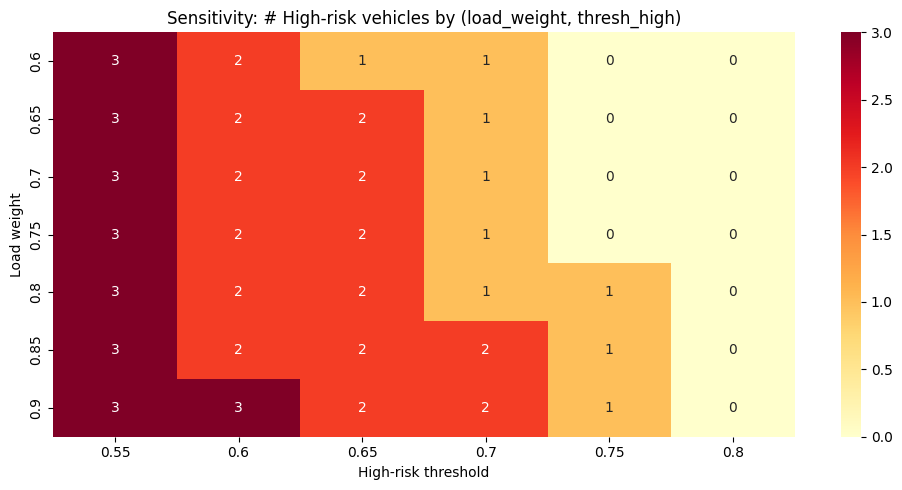


Top-1 priority vehicle for each parameter combo:


thresh_high,0.55,0.60,0.65,0.70,0.75,0.80
load_w,,,,,,
0.60,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.65,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.70,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.75,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.80,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.85,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509
0.90,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509,MH47MD4509


In [8]:
load_weights   = CONFIG['LOAD_WEIGHT_RANGE']
thresh_highs   = CONFIG['THRESH_HIGH_RANGE']

results = []
for lw, th in itertools.product(load_weights, thresh_highs):
    dw = round(1.0 - lw, 2)
    sc = lw * df['load_utilization'] + dw * df['driven_ratio']
    prio = sc / (df['load_margin_kg'] + EPS)
    top1 = df.loc[prio.idxmax(), 'vehicle_id']
    n_high = (sc >= th).sum()
    results.append({'load_w': round(lw, 2), 'thresh_high': round(th, 2),
                    'top1_vehicle': top1, 'n_high_risk': n_high})

sweep_df = pd.DataFrame(results)

# Heatmap: number of High-risk vehicles
pivot = sweep_df.pivot_table(index='load_w', columns='thresh_high',
                             values='n_high_risk', aggfunc='first')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Sensitivity: # High-risk vehicles by (load_weight, thresh_high)')
ax.set_xlabel('High-risk threshold')
ax.set_ylabel('Load weight')
plt.tight_layout()
plt.show()

# Table: top-1 vehicle per (load_w, thresh_high)
top1_pivot = sweep_df.pivot_table(index='load_w', columns='thresh_high',
                                  values='top1_vehicle', aggfunc='first')
print('\nTop-1 priority vehicle for each parameter combo:')
display(top1_pivot)

---
## 9 · Sanity Visualisations & Dashboards

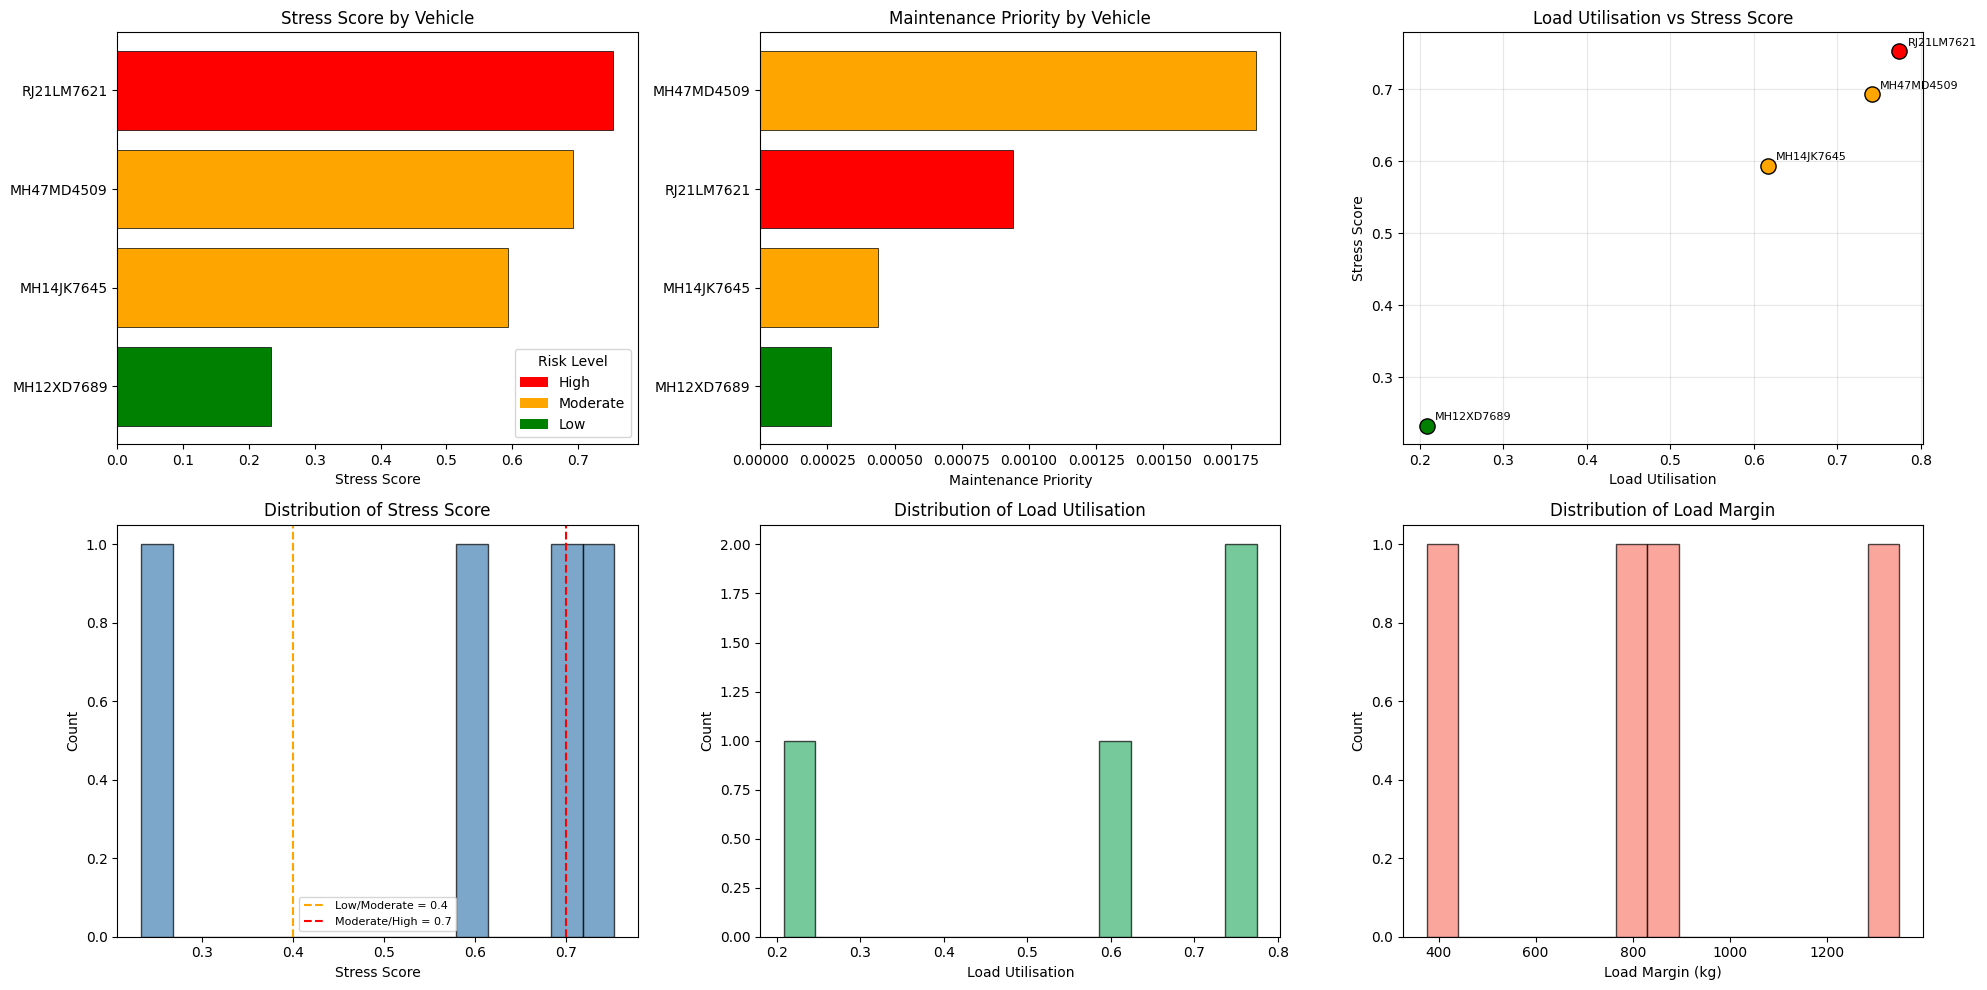


── Top 5 Highest-Priority Vehicles ──


,vehicle_id,vehicle_type,load_utilization,load_margin_kg,stress_score,risk_level,recommended_action,maintenance_priority,priority_rank
2,MH47MD4509,Box Van,0.741379,375.000000,0.693103,Moderate,Schedule maintenance check,0.001843,1
1,RJ21LM7621,Semi-Trailer,0.774648,800.000000,0.753052,High,Immediate inspection required,0.000940,2
0,MH14JK7645,TRUCK,0.617021,1350.000000,0.593617,Moderate,Schedule maintenance check,0.000439,3
3,MH12XD7689,Pickup,0.208333,886.666667,0.233333,Low,Normal monitoring,0.000263,4


In [9]:
# Color helper
RISK_COLORS = {'High': 'red', 'Moderate': 'orange', 'Low': 'green'}

sorted_df = df.sort_values('stress_score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Bar: stress_score by vehicle (colour = risk_level) ─────────
ax = axes[0, 0]
colors = sorted_df['risk_level'].map(RISK_COLORS)
ax.barh(sorted_df['vehicle_id'], sorted_df['stress_score'], color=colors,
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Stress Score')
ax.set_title('Stress Score by Vehicle')
ax.invert_yaxis()
# legend
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=r) for r, c in RISK_COLORS.items()]
ax.legend(handles=legend_el, title='Risk Level', loc='lower right')

# ── 2. Bar: maintenance_priority sorted ───────────────────────────
ax = axes[0, 1]
mp_sorted = df.sort_values('maintenance_priority', ascending=False).reset_index(drop=True)
c2 = mp_sorted['risk_level'].map(RISK_COLORS)
ax.barh(mp_sorted['vehicle_id'], mp_sorted['maintenance_priority'], color=c2,
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Maintenance Priority')
ax.set_title('Maintenance Priority by Vehicle')
ax.invert_yaxis()

# ── 3. Scatter: load_utilization vs stress_score with labels ──────
ax = axes[0, 2]
for _, row in df.iterrows():
    ax.scatter(row['load_utilization'], row['stress_score'],
              color=RISK_COLORS.get(row['risk_level'], 'gray'), s=120,
              edgecolor='black', zorder=5)
    ax.annotate(row['vehicle_id'],
                (row['load_utilization'], row['stress_score']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Load Utilisation')
ax.set_ylabel('Stress Score')
ax.set_title('Load Utilisation vs Stress Score')
ax.grid(alpha=0.3)

# ── 4. Histogram: stress_score ────────────────────────────────────
ax = axes[1, 0]
ax.hist(df['stress_score'], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
ax.axvline(THRESH_LOW,  color='orange', linestyle='--', label=f'Low/Moderate = {THRESH_LOW}')
ax.axvline(THRESH_HIGH, color='red',    linestyle='--', label=f'Moderate/High = {THRESH_HIGH}')
ax.set_xlabel('Stress Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Stress Score')
ax.legend(fontsize=8)

# ── 5. Histogram: load_utilization ────────────────────────────────
ax = axes[1, 1]
ax.hist(df['load_utilization'], bins=15, edgecolor='black', color='mediumseagreen', alpha=0.7)
ax.set_xlabel('Load Utilisation')
ax.set_ylabel('Count')
ax.set_title('Distribution of Load Utilisation')

# ── 6. Histogram: load_margin_kg ──────────────────────────────────
ax = axes[1, 2]
ax.hist(df['load_margin_kg'], bins=15, edgecolor='black', color='salmon', alpha=0.7)
ax.set_xlabel('Load Margin (kg)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Load Margin')

plt.tight_layout()
plt.show()

# ── Top-N table ───────────────────────────────────────────────────
TOP_N = CONFIG['TOP_N']
top_n = df.nsmallest(TOP_N, 'priority_rank')
print(f'\n── Top {TOP_N} Highest-Priority Vehicles ──')
display(top_n[['vehicle_id', 'vehicle_type', 'load_utilization',
               'load_margin_kg', 'stress_score', 'risk_level',
               'recommended_action', 'maintenance_priority',
               'priority_rank']])

---
## 10 · Explainability

For each vehicle produce a short, human-readable explanation of **why** it received its risk score.

In [10]:
def build_explanation(row):
    parts = []
    rl = row['risk_level']
    parts.append(f"{rl} stress:")
    parts.append(f"load_utilization={row['load_utilization']:.2f}")
    if row['load_utilization'] >= THRESH_HIGH:
        parts.append(f"(>{THRESH_HIGH})")
    elif row['load_utilization'] >= THRESH_LOW:
        parts.append(f"(>{THRESH_LOW})")
    parts.append(f", driven_ratio={row['driven_ratio']:.2f}")
    parts.append(f" -> stress_score={row['stress_score']:.2f}")
    parts.append(f" — {row['recommended_action']}.")
    return ''.join(parts)

df['explanation'] = df.apply(build_explanation, axis=1)

for _, row in df.sort_values('priority_rank').iterrows():
    print(f"  [{row['priority_rank']}] {row['vehicle_id']}: {row['explanation']}")

  [1] MH47MD4509: Moderate stress:load_utilization=0.74(>0.7), driven_ratio=0.50 -> stress_score=0.69 — Schedule maintenance check.
  [2] RJ21LM7621: High stress:load_utilization=0.77(>0.7), driven_ratio=0.67 -> stress_score=0.75 — Immediate inspection required.
  [3] MH14JK7645: Moderate stress:load_utilization=0.62(>0.4), driven_ratio=0.50 -> stress_score=0.59 — Schedule maintenance check.
  [4] MH12XD7689: Low stress:load_utilization=0.21, driven_ratio=0.33 -> stress_score=0.23 — Normal monitoring.


---
## 11 · Export Results

- **tire_intelligence_v1.csv** — complete enriched dataset  
- **maintenance_report_v1.csv** — top-priority list for ops  
- **model.info.json** — model metadata (weights, thresholds, version)

In [11]:
os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# ── Full intelligence CSV ─────────────────────────────────────────
export_cols = [
    'vehicle_id', 'vehicle_type',
    'load_per_wheel', 'max_load_single_kg', 'load_utilization',
    'load_margin_kg', 'driven_wheels', 'total_wheels', 'driven_ratio',
    'initial_tread', 'tyre_life', 'structural_index', 'adjusted_wear_rate',
    'stress_score', 'stress_score_adj',
    'risk_level', 'recommended_action',
    'maintenance_priority', 'priority_rank',
    'explanation',
    'run_timestamp', 'model_version',
]
# only keep columns that actually exist
export_cols = [c for c in export_cols if c in df.columns]

df_export = df[export_cols].sort_values('priority_rank')
df_export.to_csv(CONFIG['INTELLIGENCE_PATH'], index=False)
print(f'✓ Saved {CONFIG["INTELLIGENCE_PATH"]}  ({len(df_export)} rows)')

# ── Ops report (top-N) ────────────────────────────────────────────
df_report = df_export.head(CONFIG['TOP_N'])
df_report.to_csv(CONFIG['REPORT_PATH'], index=False)
print(f'✓ Saved {CONFIG["REPORT_PATH"]}  ({len(df_report)} rows)')

# ── Model info JSON ───────────────────────────────────────────────
model_info = {
    'model_version': MODEL_VERSION,
    'run_timestamp': RUN_TIMESTAMP,
    'formula': f'stress_score = {W_LOAD}*load_utilization + {W_DRIVEN}*driven_ratio',
    'weights': {
        'WEIGHT_LOAD':   W_LOAD,
        'WEIGHT_DRIVEN': W_DRIVEN,
    },
    'thresholds': {
        'THRESH_LOW':  THRESH_LOW,
        'THRESH_HIGH': THRESH_HIGH,
    },
    'adjusted_score': {
        'formula': f'stress_score_adj = {ALPHA}*stress_score + {BETA}*wear_norm - {GAMMA}*structural_norm',
        'ALPHA': ALPHA,
        'BETA':  BETA,
        'GAMMA': GAMMA,
    },
    'priority_formula': f'maintenance_priority = stress_score / (load_margin_kg + {EPS})',
    'input_file': CONFIG['INPUT_PATH'],
    'columns_used': export_cols,
    'n_vehicles': len(df_export),
}
with open(CONFIG['MODEL_INFO_PATH'], 'w') as f:
    json.dump(model_info, f, indent=2)
print(f'✓ Saved {CONFIG["MODEL_INFO_PATH"]}')

✓ Saved E:\TPMS\data\enriched\tire_intelligence_v1.csv  (4 rows)
✓ Saved E:\TPMS\data\enriched\maintenance_report_v1.csv  (4 rows)
✓ Saved E:\TPMS\data\enriched\model.info.json


---
## 12 · Unit Checks & Validation

In [12]:
# All stress_score in [0, 1]
assert df['stress_score'].between(0, 1).all(), 'FAIL: stress_score not in [0,1]'
print('✓ All stress_score values in [0, 1].')

# No nulls in risk_level
assert df['risk_level'].notnull().all(), 'FAIL: risk_level has nulls'
print('✓ No nulls in risk_level.')

# priority_rank is unique integers 1..N
n = len(df)
assert sorted(df['priority_rank'].tolist()) == list(range(1, n + 1)), \
       'FAIL: priority_rank not unique 1..N'
print(f'✓ priority_rank is unique integers 1..{n}.')

# risk_level valid values
assert set(df['risk_level'].unique()).issubset({'Low', 'Moderate', 'High'}), \
       'FAIL: unexpected risk_level values'
print('✓ risk_level values are valid.')

# stress_score_adj also in [0, 1]
assert df['stress_score_adj'].between(0, 1).all(), 'FAIL: stress_score_adj not in [0,1]'
print('✓ stress_score_adj values in [0, 1].')

# ── Summary ───────────────────────────────────────────────────────
counts = df['risk_level'].value_counts()
top_vehicle = df.loc[df['priority_rank'] == 1, 'vehicle_id'].values[0]

summary_parts = []
for level in ['High', 'Moderate', 'Low']:
    c = counts.get(level, 0)
    summary_parts.append(f'{c} {level} risk')

print(f'\n─── Validation Summary ───')
print(f'Run {RUN_TIMESTAMP}: {", ".join(summary_parts)}.')
print(f'Top priority vehicle: {top_vehicle}')

✓ All stress_score values in [0, 1].
✓ No nulls in risk_level.
✓ priority_rank is unique integers 1..4.
✓ risk_level values are valid.
✓ stress_score_adj values in [0, 1].

─── Validation Summary ───
Run 2026-03-01T20:06:31.187025+00:00: 1 High risk, 2 Moderate risk, 1 Low risk.
Top priority vehicle: MH47MD4509


---
## 13 · One-Line Run Summary

In [13]:
counts = df['risk_level'].value_counts()
summary_parts = []
for level in ['High', 'Moderate', 'Low']:
    c = counts.get(level, 0)
    summary_parts.append(f'{c} {level}')

print(f'🏁  Run {RUN_TIMESTAMP}:  {", ".join(summary_parts)}.')

🏁  Run 2026-03-01T20:06:31.187025+00:00:  1 High, 2 Moderate, 1 Low.


---
## 14 · Recommendations & Next Steps

### How to tune weights
- Edit `CONFIG['WEIGHT_LOAD']` and `CONFIG['WEIGHT_DRIVEN']` in cell 1.  
- Re-run the notebook — the sensitivity heatmap (cell 8) shows how ranking changes.

### How to include additional features
- Cell 7 already demonstrates `stress_score_adj` which blends structural index and wear rate.  
- To add new features: normalise them to [0, 1], add a CONFIG weight, and extend the formula.

### Evolving to time-series RUL
- This static model is the **baseline**.  
- When telemetry data streams are available, replace `load_utilization` with real-time pressure / temp signals and add survival-analysis or physics-based tread degradation curves.

### Provenance
| Field | Value |
|-------|-------|
| Cleaned file | `data/processed/cleaned_configuration_data.csv` |
| Model version | `v0.1-stress` |
| Run ID / Timestamp | See `run_timestamp` column in outputs |
| Model metadata | `data/enriched/model.info.json` |